## Hull–White + activo financiero

Voy a implementar el modelo de Hull–White con un activo financiero $ S_t $.

El objetivo es simular conjuntamente:
- el tipo corto $ r_t $, modelado mediante Hull–White;
- el precio del activo $ S_t $, cuyo drift depende del tipo de interés instantáneo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


En el modelo de Black–Scholes clásico, el tipo de interés es constante. \
Ahota, el interés  va a ser de tipo estocástico $ r_t $, modelado mediante Hull–White.

La dinámica del tipo corto viene dada por:

$ dr_t = \lambda(\theta(t)-r_t)\,dt + \eta\,dW_t^r $

Por otro lado, bajo la medida riesgo-neutral, el activo financiero sigue la dinámica:

$ dS_t = r_t S_t\,dt + \sigma_S S_t\,dW_t^S $

donde:
- $ \sigma_S $ es la volatilidad del activo;
- $ W_t^r $ y $ W_t^S $ pueden estar correlacionados.

Tenemos ncertidumbre:
- asociada a los tipos de interés;
- y otra asociada al activo financiero.

In [2]:
r_flat = 0.05

def P0T(T):
    return np.exp(-r_flat * T)

In [3]:
def GeneratePathsHWEuler(NoOfPaths, NoOfSteps, T, P0T, lambd, eta):
    """
    Simula trayectorias de r_t bajo el modelo de Hull–White
    mediante Euler.

    Parámetros
    ----------
    NoOfPaths : Número de trayectorias Monte Carlo.
    NoOfSteps : Número de pasos temporales.
    T :         Horizonte temporal.
    P0T :       Curva inicial de descuento P(0,T).
    lambd :     Velocidad de reversión a la media.
    eta :       Volatilidad del tipo corto.

    Devuelve trayectorias simuladas del tipo corto para cada t
    """

    ## 1. DERIVADAS NUMÉRICAS SOBRE LA CURVA
    
    # Paso pequeño SOLO para derivar la curva P(0,T)
    dt_diff = 1e-4

    # Forward instantáneo inicial:
    # f(0,t) = - d/dt log P(0,t)
    f0T = lambda t: -(np.log(P0T(t + dt_diff)) - np.log(P0T(t - dt_diff))) / (2 * dt_diff)

    # Tipo corto inicial: en t ~ 0
    r0 = f0T(1e-5)

    # Función theta(t), para calcular P(0,T)
    theta = lambda t: (
        1.0 / lambd * (f0T(t + dt_diff) - f0T(t - dt_diff)) / (2.0 * dt_diff)
        + f0T(t)
        + eta * eta / (2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))
    )

    # Variables normales estándar
    Z = np.random.normal(0.0, 1.0, [NoOfPaths, NoOfSteps])

    # Browniano 
    W = np.zeros([NoOfPaths, NoOfSteps + 1])

    # Trayectorias del tipo corto
    R = np.zeros([NoOfPaths, NoOfSteps + 1])
    R[:, 0] = r0

    # Malla temporal
    time = np.zeros([NoOfSteps + 1])

    dt = T / float(NoOfSteps)

    for i in range(NoOfSteps):

        # Normalización
        if NoOfPaths > 1:
            Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])

        # Incremento del movimiento browniano
        W[:, i + 1] = W[:, i] + np.sqrt(dt) * Z[:, i]

        #Euler para el short rate:
        R[:, i + 1] = (
            R[:, i]
            + lambd * (theta(time[i]) - R[:, i]) * dt
            + eta * (W[:, i + 1] - W[:, i])
        )
        
        time[i + 1] = time[i] + dt

    paths = {"time": time, "R": R}
    return paths

Tenemos que el activo:
* crece en media al tipo libre de riesgo instantáneo $r_t$
* tiene ruido propio
* puede estar correlacionado con el ruido de tipos

### Correlación entre el activo y el tipo de interés

Para simular conjuntamente $ r_t $ y $ S_t $, se introducen dos variables normales estándar correlacionadas.

Si $ Z_1 $ y $ Z_2 $  son normales estándar independientes, se define:

$ Z_r = Z_1 $
$ Z_S = \rho Z_1 + \sqrt{1-\rho^2} Z_2 $

De este modo:
- $ Z_r $ genera el shock del tipo corto;
- $ Z_S $ genera el shock del activo;
- la correlación entre ambos es $ \rho $.

In [4]:
def GeneratePathsHWAndAssetEuler(NoOfPaths, NoOfSteps, T, P0T, lambd, eta, S0, sigma_S, rho):
    """
    Simula trayectorias de:
    - r_t: bajo Hull–White
    - S_t: activo financiero bajo medida riesgo-neutral

    NoOfPaths : Número de trayectorias Monte Carlo.
    NoOfSteps : Número de pasos temporales.
    T : Horizonte temporal.
    P0T : Curva inicial de descuento P(0,T).
    lambd : Velocidad de reversión a la media del short rate.
    eta : Volatilidad del short rate.
    S0 : Precio inicial del activo.
    sigma_S : Volatilidad del activo.
    rho : Correlación entre el shock del short rate y el shock del activo.

    Devuelve
        "R": trayectorias del short rate
        "S": trayectorias del activo
    """

    dt_diff = 1e-4

    f0T = lambda t: -(np.log(P0T(t + dt_diff)) - np.log(P0T(t - dt_diff))) / (2 * dt_diff)

    r0 = f0T(1e-5)

    theta = lambda t: (1.0 / lambd * (f0T(t + dt_diff) - f0T(t - dt_diff)) / (2.0 * dt_diff)
        + f0T(t)
        + eta * eta / (2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t)))

    # =========================

    dt = T / float(NoOfSteps)

    time = np.zeros([NoOfSteps + 1])

    R = np.zeros([NoOfPaths, NoOfSteps + 1])
    S = np.zeros([NoOfPaths, NoOfSteps + 1])

    R[:, 0] = r0
    S[:, 0] = S0

     # SIMULACIÓN

    for i in range(NoOfSteps):

        # Normales independientes
        Z1 = np.random.normal(0.0, 1.0, NoOfPaths)
        Z2 = np.random.normal(0.0, 1.0, NoOfPaths)

        # Normalización opcional
        if NoOfPaths > 1:
            Z1 = (Z1 - np.mean(Z1)) / np.std(Z1)
            Z2 = (Z2 - np.mean(Z2)) / np.std(Z2)

        # Correlacionamos
        Z_r = Z1
        Z_S = rho * Z1 + np.sqrt(1.0 - rho**2) * Z2

        # Short rate:
        R[:, i + 1] = (
            R[:, i]
            + lambd * (theta(time[i]) - R[:, i]) * dt
            + eta * np.sqrt(dt) * Z_r)

        # Activo:
        S[:, i + 1] = (
            S[:, i]
            * np.exp((R[:, i] - 0.5 * sigma_S**2) * dt + sigma_S * np.sqrt(dt) * Z_S))

        time[i + 1] = time[i] + dt

    return {"time": time, "R": R, "S": S}

In [5]:
NoOfPaths = 5
NoOfSteps = 300
T = 1.0

lambd = 0.5
eta = 0.01

S0 = 100.0
sigma_S = 0.20
rho = -0.3

paths_joint = GeneratePathsHWAndAssetEuler(
    NoOfPaths=NoOfPaths,
    NoOfSteps=NoOfSteps,
    T=T,
    P0T=P0T,
    lambd=lambd,
    eta=eta,
    S0=S0,
    sigma_S=sigma_S,
    rho=rho
)

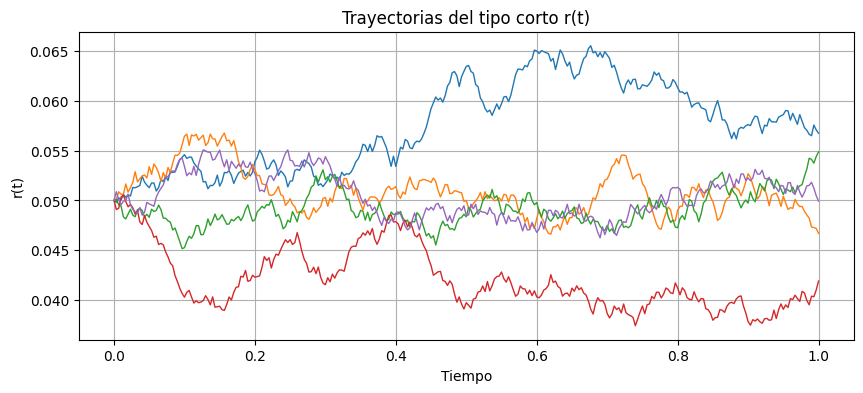

In [6]:
time = paths_joint["time"]
R = paths_joint["R"]
S = paths_joint["S"]

plt.figure(figsize=(10, 4))
for i in range(NoOfPaths):
    plt.plot(time, R[i, :], lw=1)

plt.title("Trayectorias del tipo corto r(t)")
plt.xlabel("Tiempo")
plt.ylabel("r(t)")
plt.grid(True)
plt.show()

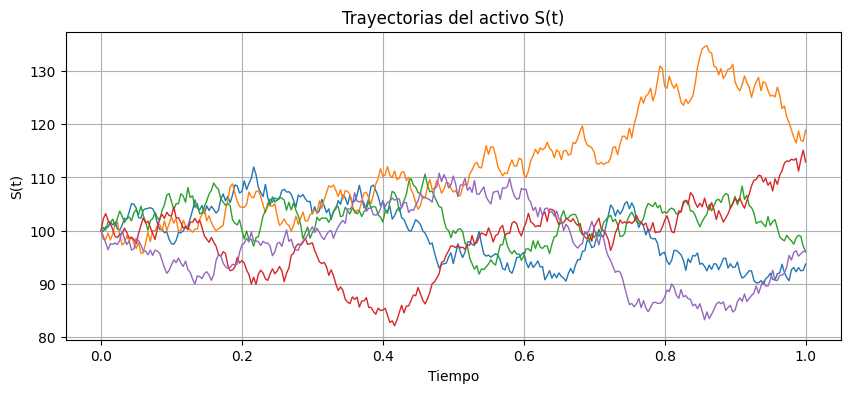

In [7]:
plt.figure(figsize=(10, 4))
for i in range(NoOfPaths):
    plt.plot(time, S[i, :], lw=1)

plt.title("Trayectorias del activo S(t)")
plt.xlabel("Tiempo")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

El tipo corto evoluciona “por su cuenta”\
El activo sí depende del tipo\
No hay feedback del activo al tipo

In [8]:
np.mean(R)

np.float64(0.05001161828852595)

Cuando introducimos el activo financiero no altera la dinámica del tipo corto, cuyas trayectorias se mantienen similares a las del modelo de Hull–White del otro notebook. El tipo de interés evoluciona de manera independiente, mientras que el **activo depende de él a través de su drift bajo medida riesgo-neutral**.